## Experiment 2: Frozen Image Encoder

To align with the original VL-JEPA paper's experiments, we freeze the image encoder. This allows us to make a single localized change to the original VL-JEPA setup and assess the impact.

In [1]:
import json
import os

import pandas as pd
from plotly import express as px
from plotly import subplots

import dotenv

from mole_jepa import config, model_io, registry

dotenv.load_dotenv()
ROOT = os.environ.get("CHECKPOINT_DIR")

/home/vpathak/mole_jepa/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [28]:
def process_train_val_stats(
    train_stats: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if "val_loss_reg_image" in train_stats:
        train_losses = pd.melt(
            train_stats,
            id_vars="epoch",
            value_vars=["train_loss_mse", "train_loss_reg_text"],
            var_name="loss_type",
            value_name="loss",
        )
        
        val_losses = pd.melt(
            train_stats,
            id_vars="epoch",
            value_vars=["val_loss_mse", "val_loss_reg_text"],
            var_name="loss_type",
            value_name="loss",
        )
    else:
        train_losses = train_stats.copy()
        train_losses["loss_type"] = "InfoNCE"
        train_losses["loss"] = train_losses["train_loss"]
        train_losses = train_losses[["epoch", "loss_type", "loss"]].copy()
        
        val_losses = train_stats.copy()
        val_losses["loss_type"] = "InfoNCE"
        val_losses["loss"] = val_losses["val_loss"]
        val_losses = val_losses[["epoch", "loss_type", "loss"]].copy()

    return train_losses, val_losses

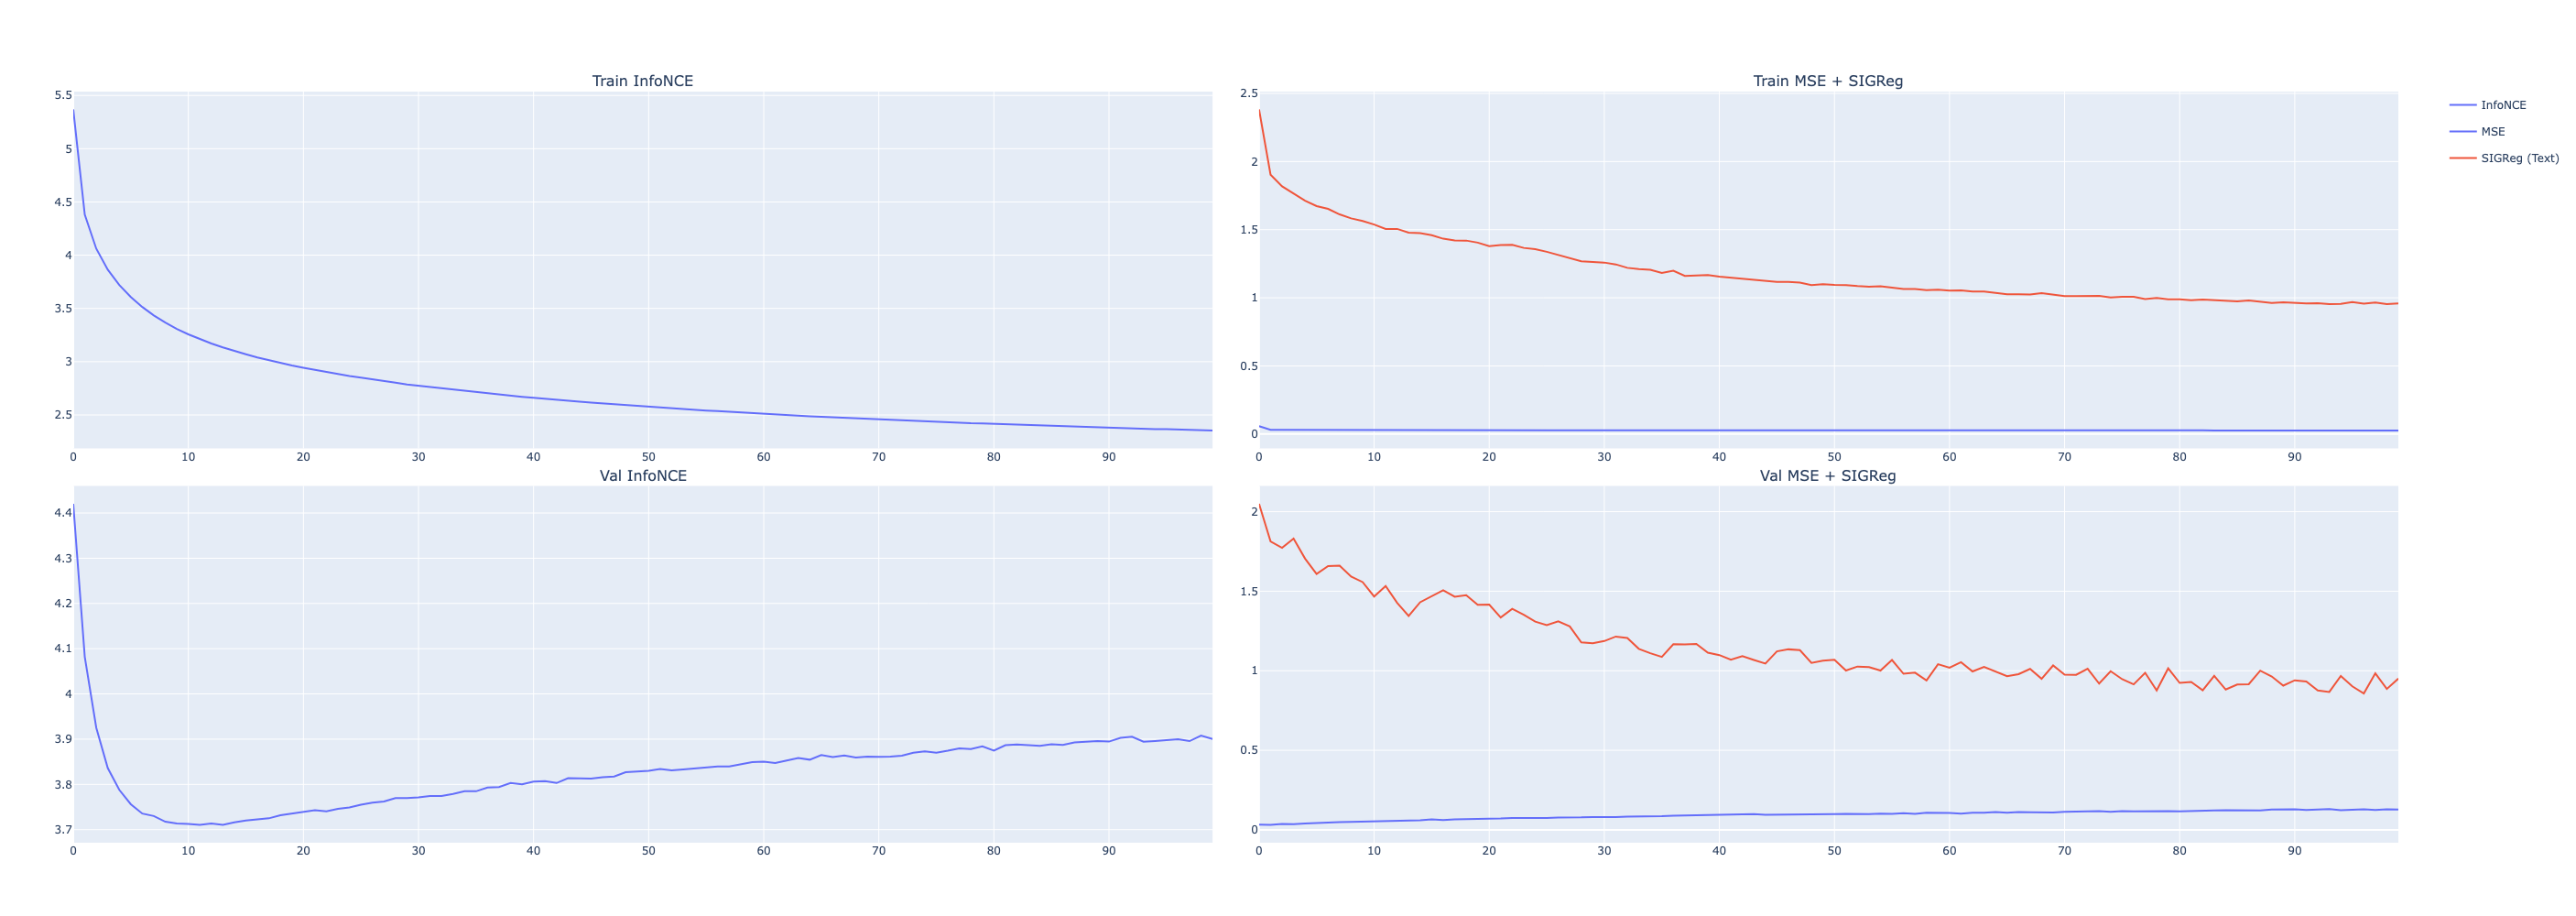

In [32]:
all_subplots = [[], []]
all_titles = [[], []]

model_train_losses = {}
model_val_losses = {}

for model_name, model_cfg in registry.CONFIGS.items():
    if model_name.endswith("_frozen") and "tiny" in model_name:
        model_path = model_io.model_dir(ROOT, model_cfg)
        train_stats = pd.read_json(model_path / "stats.jsonl", lines=True)
        train_losses, val_losses = process_train_val_stats(train_stats)

        if model_cfg.sigreg_demean:
            continue
        elif model_cfg.contrastive:
            title = "InfoNCE"
        else:
            title = "MSE + SIGReg"
        
        model_train_losses[model_name] = train_losses
        model_val_losses[model_name] = val_losses
        
        all_subplots[0].append(
            px.line(
                train_losses,
                x="epoch",
                y="loss",
                color="loss_type",
            ),
        )
        all_titles[0].append("Train " + title)

        all_subplots[1].append(
            px.line(
                val_losses,
                x="epoch",
                y="loss",
                color="loss_type",
            ),
        )
        all_titles[1].append("Val " + title)

fig = subplots.make_subplots(
    len(all_subplots),
    len(all_subplots[0]),
    subplot_titles=[t for l in all_titles for t in l],
    vertical_spacing=0.05,  # Decrease this for a "tighter" layout
    horizontal_spacing=0.02,
)

for i, plot_l in enumerate(all_subplots):
    for j, plot in enumerate(plot_l):
        for trace in plot.data:
            fig.add_trace(
                trace, row=i + 1, col=j + 1
            )

# Legend name mapping
fig.for_each_trace(
    lambda t: t.update(
        name=t.name.replace("val_loss_mse", "MSE")
            .replace("val_loss_reg_text", "SIGReg (Text)")
            .replace("train_loss_mse", "MSE")
            .replace("train_loss_reg_text", "SIGReg (Text)")
    ),
)

# Make sure no duplicates in legend
names = set()
fig.for_each_trace(
    lambda trace:
        trace.update(showlegend=False)
        if (trace.name in names) else names.add(trace.name))

fig.update_layout(height=1000, width=2000)
fig.show()

Specifically focusing on the InfoNCE above, we'd expect the validation loss to steadily decrease. Instead, it steadily _increases_ after a sharp decrease contrasting with the convergence of the train InfoNCE. This leads me to believe that the model is overfitting, and given these experiments were ran using a 10mm parameter model, it's likely the case that CC3M's small size is the bottleneck here.

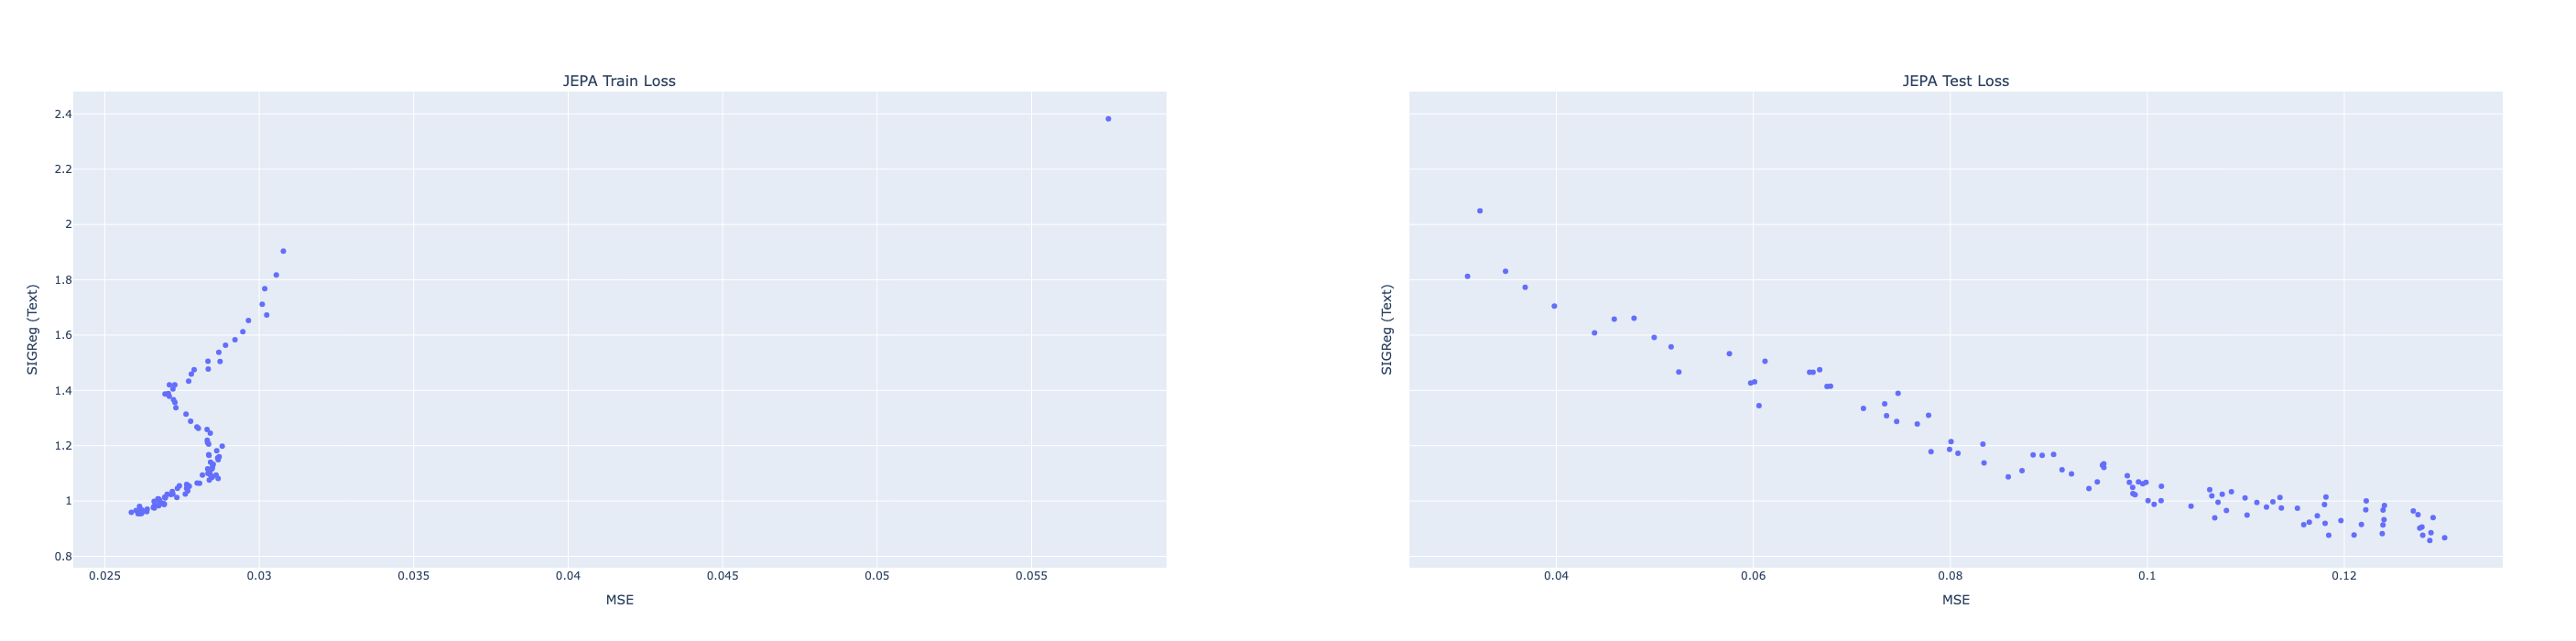

In [56]:
jepa_train_loss = model_train_losses["vit_tiny_bert_tiny_jepa_frozen"].pivot_table(
    index="epoch", columns="loss_type", values="loss",
)

jepa_val_loss = model_val_losses["vit_tiny_bert_tiny_jepa_frozen"].pivot_table(
    index="epoch", columns="loss_type", values="loss",
)

scatter_titles = ["JEPA Train Loss", "JEPA Test Loss"]
scatters = []

scatters = [
    px.scatter(
        jepa_train_loss,
        x="train_loss_mse",
        y="train_loss_reg_text",
        labels={
            "train_loss_mse": "MSE",
            "train_loss_reg_text": "SIGReg (Text)",
        },
    ),
    px.scatter(
        jepa_loss,
        x="val_loss_mse",
        y="val_loss_reg_text",
        labels={
            "val_loss_mse": "MSE",
            "val_loss_reg_text": "SIGReg (Text)",
        },
    ),
]

scatter_subplots = subplots.make_subplots(
    1, 2, subplot_titles=scatter_titles, shared_yaxes=True
)

for i, plot in enumerate(scatters):
    for trace in plot.data:
        scatter_subplots.add_trace(
            trace, row=1, col=i + 1
        )

scatter_subplots.update_layout(width=1000, height=700)
scatter_subplots.update_xaxes(title_text="MSE")
scatter_subplots.update_yaxes(title_text="SIGReg (Text)")
scatter_subplots.show()

Above, I'm just inspecting whether there is a causal relationship between MSE and SIGReg to see whether one is hurting the other's convergence. It doesn't appear that way given the training losses, but we see a clear negative correlation in the validation setting. That doesn't necessarily imply some kind of causal relationship though, and warrants further investigation.